## Financial Distress Index (FDI) 

This notebook builds a **Financial Distress Index (FDI)** for Kenya’s mobile money ecosystem by combining outputs from multiple analytical pipelines, including sentiment classification models, topic modeling (LDA), explainability analysis (SHAP), time-series complaint aggregation, and anomaly detection.

It integrates and standardizes monthly data on complaints, ratings, and sentiment signals, then transforms them into comparable metrics to construct a single composite index representing financial and operational stress.

The FDI goes beyond basic sentiment analysis by tracking financial distress over time, detecting systemic shocks in mobile money services, and quantifying user dissatisfaction as a financial risk indicator.

### Output of this notebook includes:
- Monthly Financial Distress Index (FDI)
- Distress level classification (Green, Yellow, Orange, Red)
- Trend analysis of financial stress in Kenya’s fintech ecosystem
- Foundation for forecasting and early warning systems

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## Step 1: Load Monthly Financial Distress Dataset

This step loads the preprocessed monthly dataset that includes complaint metrics, rating trends, rolling averages, Z-score anomalies, and early warning signals.

It serves as the foundational input for building the Financial Distress Index (FDI).

In [23]:
# Loading the dataset
df = pd.read_csv('monthly_summary.csv')

# Converting the 'year_month' column to datetime format
df['year_month'] = pd.to_datetime(df['year_month']) # Ensure 'year_month' is in datetime format
# Sorting the DataFrame by 'year_month' 
df = df.sort_values('year_month').reset_index(drop=True)

df.head()

,year_month,total_reviews,complaints,average_rating,complaint_rate,rolling_avg_complaints,z_score,complaint_anomaly,rolling_spike,alert
0,2023-05-01,781,86,4.469910,0.110115,NaN,-0.302817,False,False,Normal
1,2023-06-01,876,89,4.494292,0.101598,NaN,-0.298540,False,False,Normal
2,2023-07-01,833,87,4.497602,0.104442,87.333333,-0.301391,False,False,Normal
3,2023-08-01,684,50,4.589181,0.073099,75.333333,-0.354147,False,False,Normal
4,2023-09-01,716,51,4.638268,0.071229,62.666667,-0.352722,False,False,Normal


## Step 2: Construct Core Financial Distress Indicators

This step builds the main components of financial distress:

- Complaint Pressure: intensity of user dissatisfaction
- Rating Stress: decline in user satisfaction
- Trend Acceleration: growth rate of complaints
- Shock Intensity: standardized anomaly signal (z-score based)

These indicators form the foundation of the Financial Distress Index (FDI).

In [24]:
# Complaint Pressure Index
df['complaint_pressure'] = df['complaint_rate']

# Rating Stress Index
df['rating_stress'] = (5 - df['average_rating']) / 5

# Trend Acceleration (complaint growth vs rolling average)
df['trend_acceleration'] = df['complaints'] / (df['rolling_avg_complaints'] + 1e-6)

# Shock Intensity (standardized anomaly signal)
df['shock_intensity'] = (
    df['z_score'] - df['z_score'].mean()
) / (df['z_score'].std() + 1e-6)

# Preview new distress features
df[['year_month', 'complaint_pressure', 'rating_stress', 'trend_acceleration', 'shock_intensity']].head()

,year_month,complaint_pressure,rating_stress,trend_acceleration,shock_intensity
0,2023-05-01,0.110115,0.106018,NaN,-0.302817
1,2023-06-01,0.101598,0.101142,NaN,-0.298539
2,2023-07-01,0.104442,0.100480,0.996183,-0.301391
3,2023-08-01,0.073099,0.082164,0.663717,-0.354147
4,2023-09-01,0.071229,0.072346,0.813830,-0.352721


# Step 3: Normalize Financial Distress Indicators

All indicators are scaled between 0 and 1 to ensure fair contribution to the Financial Distress Index (FDI).

This prevents any single metric from dominating the final score due to scale differences.

In [25]:
# Selecting features to normalize
features = [
    'complaint_pressure',
    'rating_stress',
    'trend_acceleration',
    'shock_intensity'
]

scaler = MinMaxScaler()

df[[f + '_norm' for f in features]] = scaler.fit_transform(df[features])

# Preview normalized values
df[['year_month'] + [f + '_norm' for f in features]].head()

,year_month,complaint_pressure_norm,rating_stress_norm,trend_acceleration_norm,shock_intensity_norm
0,2023-05-01,0.147058,0.155685,NaN,0.013393
1,2023-06-01,0.114848,0.133139,NaN,0.014098
2,2023-07-01,0.125602,0.130078,0.215767,0.013628
3,2023-08-01,0.007073,0.045392,0.045614,0.004934
4,2023-09-01,0.000000,0.000000,0.122440,0.005169


## Step 4: Financial Distress Index (FDI) Construction

This step combines all normalized distress indicators into a single composite index:

### Financial Distress Index (FDI)

The index represents overall system stress in Kenya’s mobile money ecosystem.

Higher values indicate:
- higher complaint intensity
- lower user satisfaction
- abnormal system behavior
- increasing financial distress risk

The index is computed using equal weighting of all signals.

In [38]:
# Filling any potential NaN values with 0 (if any)
df['fdi_momentum'] = df['fdi_momentum'].fillna(0)

# Financial Distress Index
df['FDI'] = (
    df['complaint_pressure_norm'] +
    df['rating_stress_norm'] +
    df['trend_acceleration_norm'] +
    df['shock_intensity_norm']
) / 4                                         # Average of the normalized components

# Preview FDI
df[['year_month', 'FDI']].head()

,year_month,FDI
0,2023-05-01,0.079034
1,2023-06-01,0.065521
2,2023-07-01,0.121269
3,2023-08-01,0.025753
4,2023-09-01,0.031902


## Step 5: Financial Distress Classification

The Financial Distress Index is categorized into:

- Low Distress (Stable system)
- Medium Distress (Warning zone)
- High Distress (Crisis zone)

This allows early warning detection of fintech instability.

In [27]:
# Classifying distress levels based on FDI thresholds
df['distress_level'] = pd.cut(
    df['FDI'],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=['Low', 'Medium', 'High']
)

# Preview classification
df[['year_month', 'FDI', 'distress_level']].head()

,year_month,FDI,distress_level
0,2023-05-01,0.079034,Low
1,2023-06-01,0.065521,Low
2,2023-07-01,0.121269,Low
3,2023-08-01,0.025753,Low
4,2023-09-01,0.031902,Low


In [28]:
df['distress_level'] = pd.cut(
    df['FDI'],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=['Low', 'Medium', 'High']
)

## Step 6: Financial Distress Dynamics (Post-Classification Signals)

After classifying Financial Distress Index (FDI) into Low, Medium, and High risk levels, we introduce dynamic indicators to capture how distress evolves over time.

These include:

- **FDI Momentum**: measures month-to-month change in financial distress
- **Rolling Mean and Standard Deviation**: smooths short-term fluctuations and captures trend stability
- **Risk Signal Indicator**: flags periods where distress is rising above its recent trend

This step enhances the static classification by introducing temporal behavior analysis, enabling early detection of emerging financial instability.

In [30]:
# Measure momentum by looking at month-over-month changes in FDI
df['fdi_momentum'] = df['FDI'].diff()

In [31]:
# Smoothing FDI with a rolling mean and standard deviation
df['fdi_rolling_mean'] = df['FDI'].rolling(window=3).mean()
df['fdi_rolling_std'] = df['FDI'].rolling(window=3).std()

In [32]:
# Early warning signal: If FDI is rising and above its rolling mean, it may indicate increasing risk
df['risk_signal'] = np.where(
    (df['fdi_momentum'] > 0) & 
    (df['FDI'] > df['fdi_rolling_mean']),
    'Rising Risk',
    'Stable'
)

## Step 7: Financial Distress Visualization

### 1. Financial Distres Index over time

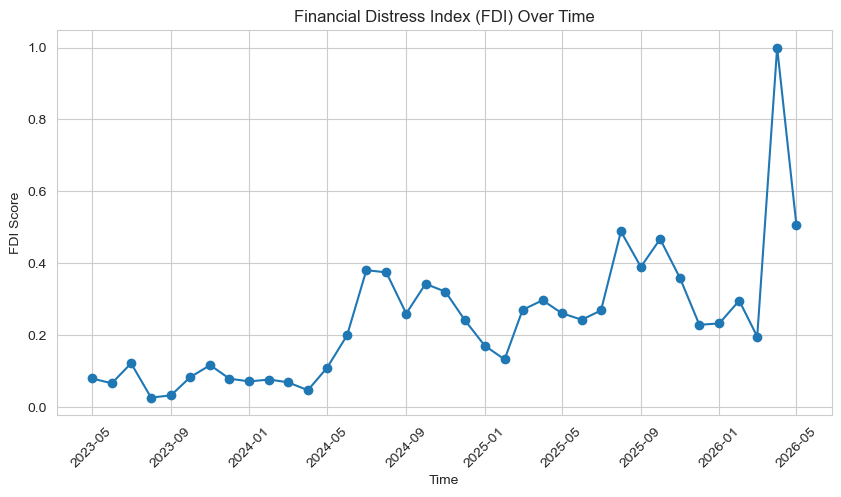

In [29]:
# Visualizing FDI over time
plt.figure(figsize=(10,5))

plt.plot(df['year_month'], df['FDI'], marker='o')

plt.title("Financial Distress Index (FDI) Over Time")
plt.xlabel("Time")
plt.ylabel("FDI Score")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

### 2. Financial Distres Index vs Rolling Trend

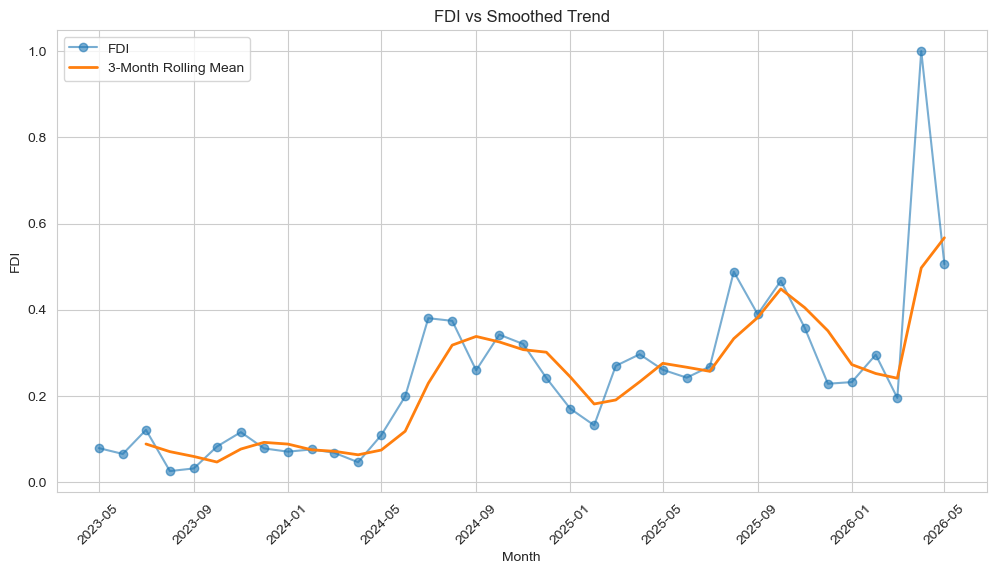

In [33]:
plt.figure(figsize=(12,6))

plt.plot(df['year_month'], df['FDI'], marker='o', label='FDI', alpha=0.6)
plt.plot(df['year_month'], df['fdi_rolling_mean'], label='3-Month Rolling Mean', linewidth=2)

plt.title('FDI vs Smoothed Trend')
plt.xlabel('Month')
plt.ylabel('FDI')
plt.xticks(rotation=45)

plt.grid(True)
plt.legend()
plt.show()

### 3. Distress Level Distribution

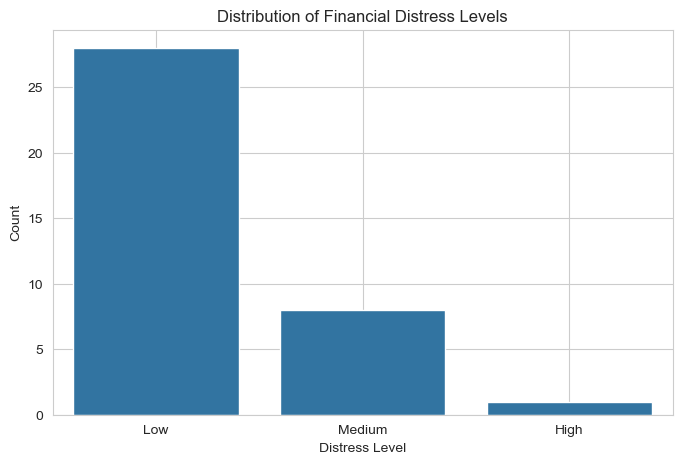

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='distress_level', order=['Low', 'Medium', 'High'])

plt.title('Distribution of Financial Distress Levels')
plt.xlabel('Distress Level')
plt.ylabel('Count')

plt.grid(True)
plt.show()

### 4. Risk Signal over Time

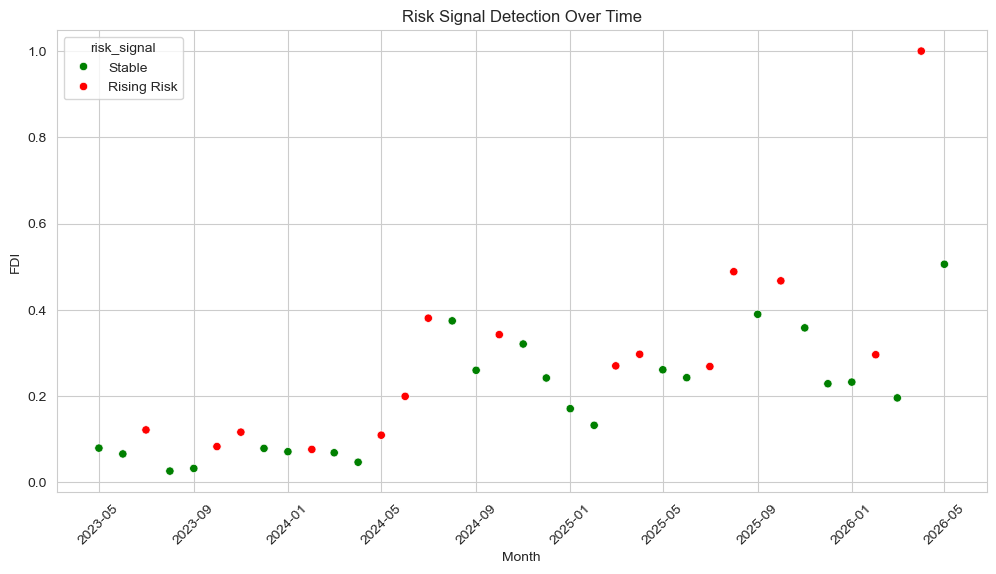

In [35]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='year_month',
    y='FDI',
    hue='risk_signal',
    palette={'Stable': 'green', 'Rising Risk': 'red'}
)

plt.title('Risk Signal Detection Over Time')
plt.xlabel('Month')
plt.ylabel('FDI')
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

### 5. Momentum Visualization

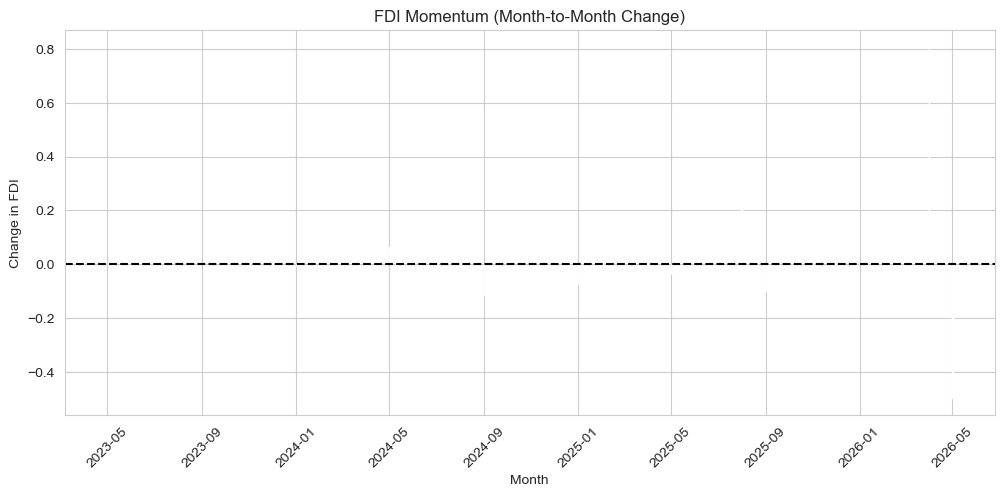

In [39]:
plt.figure(figsize=(12,5))

plt.bar(df['year_month'], df['fdi_momentum'], color='orange')

plt.axhline(0, color='black', linestyle='--')

plt.title('FDI Momentum (Month-to-Month Change)')
plt.xlabel('Month')
plt.ylabel('Change in FDI')
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

### 6. Combined Risk Dashboard

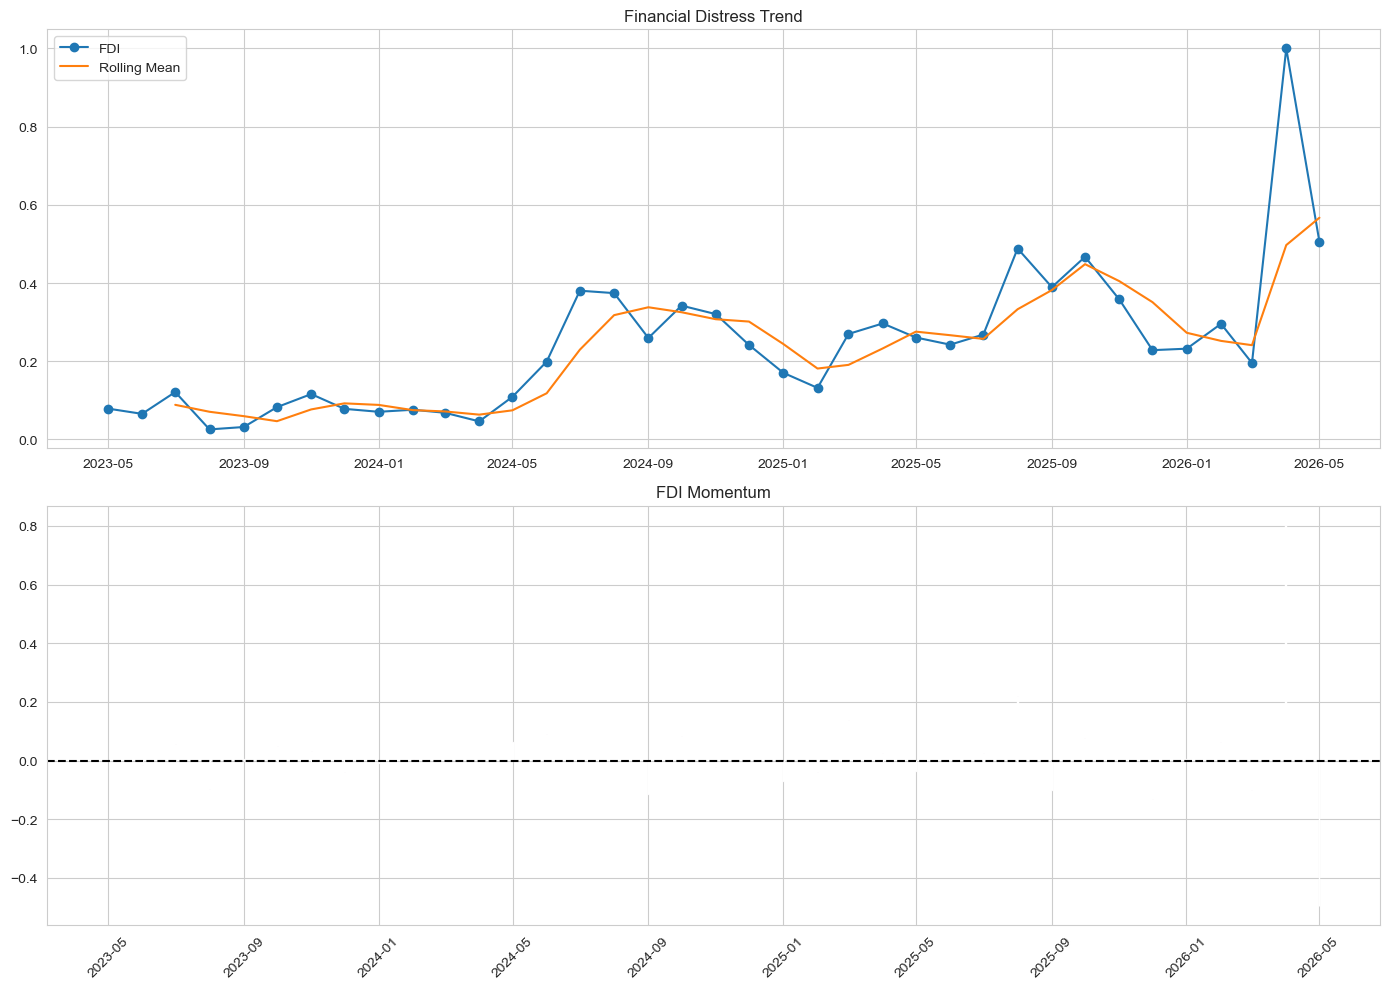

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(14,10))

# FDI line
ax[0].plot(df['year_month'], df['FDI'], marker='o', label='FDI')
ax[0].plot(df['year_month'], df['fdi_rolling_mean'], label='Rolling Mean')
ax[0].set_title('Financial Distress Trend')
ax[0].legend()
ax[0].grid(True)

# Momentum
ax[1].bar(df['year_month'], df['fdi_momentum'], color='purple')
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title('FDI Momentum')
ax[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
df['alert_level'] = np.where(
    (df['distress_level'] == 'High') & (df['fdi_momentum'] > 0),
    'RED',
    np.where(
        (df['distress_level'] == 'Medium'),
        'AMBER',
        'GREEN'
    )
)

In [42]:
summary = df[['year_month', 'FDI', 'distress_level', 'fdi_momentum', 'risk_signal', 'alert_level']]
summary

,year_month,FDI,distress_level,fdi_momentum,risk_signal,alert_level
0,2023-05-01,0.079034,Low,0.000000,Stable,GREEN
1,2023-06-01,0.065521,Low,-0.013513,Stable,GREEN
2,2023-07-01,0.121269,Low,0.055747,Rising Risk,GREEN
3,2023-08-01,0.025753,Low,-0.095515,Stable,GREEN
4,2023-09-01,0.031902,Low,0.006149,Stable,GREEN
5,2023-10-01,0.082663,Low,0.050760,Rising Risk,GREEN
6,2023-11-01,0.116070,Low,0.033407,Rising Risk,GREEN
7,2023-12-01,0.078349,Low,-0.037720,Stable,GREEN
8,2024-01-01,0.070798,Low,-0.007552,Stable,GREEN
9,2024-02-01,0.076002,Low,0.005205,Rising Risk,GREEN


In [43]:
df[df['alert_level'] == 'RED']

,year_month,total_reviews,complaints,average_rating,complaint_rate,rolling_avg_complaints,z_score,complaint_anomaly,rolling_spike,alert,complaint_pressure,rating_stress,trend_acceleration,shock_intensity,complaint_pressure_norm,rating_stress_norm,trend_acceleration_norm,shock_intensity_norm,FDI,distress_level,fdi_momentum,fdi_rolling_mean,fdi_rolling_std,risk_signal,alert_level
35,2026-04-01,12766,4285,3.55687,0.335657,1694.666667,5.684279,True,True,Complaint spike detected,0.335657,0.288626,2.528521,5.684273,1.0,1.0,1.0,1.0,1.0,High,0.8045,0.497068,0.438424,Rising Risk,RED


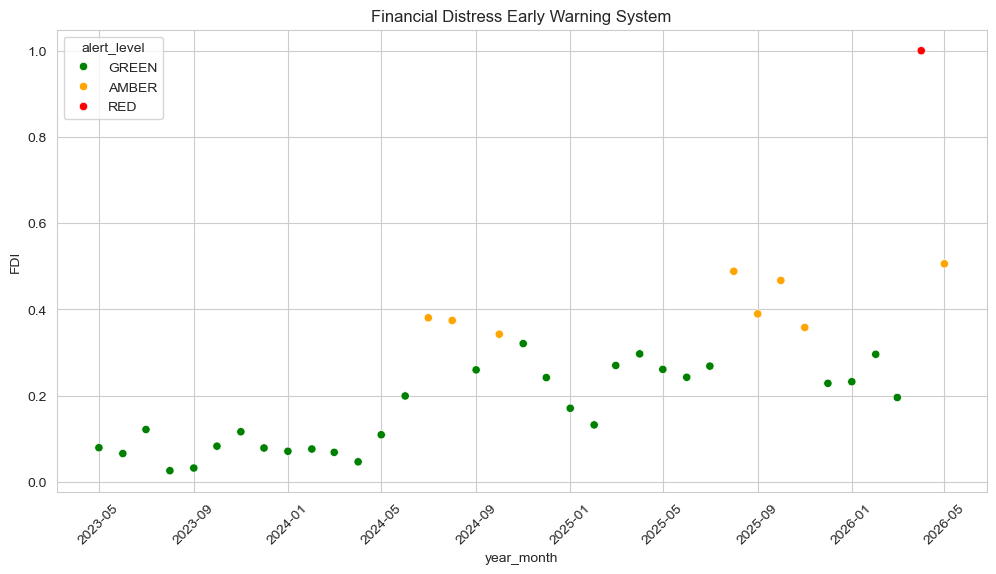

In [44]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='year_month',
    y='FDI',
    hue='alert_level',
    palette={'GREEN':'green','AMBER':'orange','RED':'red'}
)

plt.title("Financial Distress Early Warning System")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

##  Automated Financial Distress Alert Messages

This step generates automated alert messages based on detected changes in complaint pressure, financial distress trends, anomaly intensity, and risk escalation signals.

The alerts provide interpretable warnings that can support early warning systems and financial risk monitoring within Kenya’s mobile money ecosystem.

In [45]:
# Function to generate automated financial distress alerts

def generate_alert_message(row):

    # Rising complaint pressure
    if row['complaint_pressure'] > 0.10 and row['fdi_momentum'] > 0:
        return "WARNING: Complaint pressure increased significantly this month."

    # High financial distress
    elif row['distress_level'] == 'High':
        return "HIGH ALERT: Financial distress levels remain critically high."

    # Anomaly-based warning
    elif row['shock_intensity'] > 1:
        return "ANOMALY ALERT: Unusual complaint behavior detected this month."

    # Rising risk trend
    elif row['risk_signal'] == 'Rising Risk':
        return "RISK SIGNAL: Financial distress trend is increasing."

    # Stable system
    else:
        return "STABLE: No significant financial distress detected."


# Apply alert generation
df['alert_message'] = df.apply(generate_alert_message, axis=1)

# Preview alerts
df[['year_month', 'FDI', 'distress_level', 'alert_message']].head()

,year_month,FDI,distress_level,alert_message
0,2023-05-01,0.079034,Low,STABLE: No significant financial distress dete...
1,2023-06-01,0.065521,Low,STABLE: No significant financial distress dete...
2,2023-07-01,0.121269,Low,WARNING: Complaint pressure increased signific...
3,2023-08-01,0.025753,Low,STABLE: No significant financial distress dete...
4,2023-09-01,0.031902,Low,STABLE: No significant financial distress dete...


## Summary of Findings

- A Financial Distress Index (FDI) was successfully developed using:
  - Complaint Pressure
  - Rating Stress
  - Trend Acceleration

- The indicators were normalized and combined into a composite score to measure overall financial distress trends.

- Earlier periods showed relatively low financial distress, indicating stable operational conditions.

- The analysis identified a gradual increase in financial distress over time, driven mainly by:
  - Increasing customer complaints
  - Declining customer ratings

- Rolling averages and momentum analysis helped detect changes in distress patterns and identify early warning signals.

- Distress levels were categorized into different risk classes, improving interpretability of financial health status.

- A critical high-risk period was detected in April 2026, where:
  - Complaint levels sharply increased
  - Complaint rates became significantly high
  - Average customer ratings declined

- The alert system successfully generated automated risk warnings, including RED alerts during severe distress periods.

- Visualizations clearly illustrated:
  - Trends in financial distress
  - Changes in complaint behavior
  - Variations in customer satisfaction over time

## Conclusion

The notebook demonstrates that customer complaints, customer ratings, and trend-based indicators can effectively be used to build a Financial Distress Monitoring System. The Financial Distress Index provides a practical approach for detecting risk patterns early and supporting data-driven decision-making.